<a href="https://colab.research.google.com/github/jagadeeshy429-yt/Suicide-Risk-Assessment-Agent/blob/main/Crop_Yield_Prediction_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving crop yield.csv to crop yield (1).csv


In [ ]:
df = pd.read_csv("/content/crop yield.csv")

In [ ]:
df.head()

,Domain,Area,Element,Item,Year,Unit,yield
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   object 
 1   Area     4349 non-null   object 
 2   Element  4349 non-null   object 
 3   Item     4349 non-null   object 
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   object 
 6   yield    4349 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 238.0+ KB


In [ ]:
df.isnull().sum()

,0
Domain,0
Area,0
Element,0
Item,0
Year,0
Unit,0
yield,0


In [ ]:
df = df.drop(columns=['Unnamed: 7', 'Unnamed: 8'], errors='ignore')

In [ ]:
label_encoders = {}

for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [ ]:
target = "yield"

X = df.drop(target, axis=1)

y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),

    "SVR":
        SVR(),

    "MLP":
        MLPRegressor(
            hidden_layer_sizes=(100,50),
            max_iter=500,
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        )
}

In [ ]:
results = []

best_model = None

best_score = -999

for name, model in models.items():

    if name in ["SVR","MLP"]:
        model.fit(X_train_scaled,y_train)
        prediction = model.predict(X_test_scaled)

    else:
        model.fit(X_train,y_train)
        prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test,prediction)

    rmse = np.sqrt(mean_squared_error(y_test,prediction))

    r2 = r2_score(y_test,prediction)

    results.append([name,mae,rmse,r2])

    print("="*50)

    print(name)

    print("MAE :",mae)

    print("RMSE :",rmse)

    print("R2 :",r2)

    if r2 > best_score:
        best_score = r2
        best_model = model

Linear Regression
MAE : 33316.94246756271
RMSE : 132464.16613019977
R2 : 0.0028701322192357104
Decision Tree
MAE : 1449.834022988506
RMSE : 6678.315410814645
R2 : 0.9974655206422103
Random Forest
MAE : 1170.7314853448277
RMSE : 4193.904273527
R2 : 0.9990004789791255
SVR
MAE : 22450.01819231243
RMSE : 134393.7228604593
R2 : -0.02639109275217022


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP
MAE : 33230.11020296031
RMSE : 132147.13626220846
R2 : 0.007637333351527276
XGBoost
MAE : 2902.7339762029537
RMSE : 10473.764221203057
R2 : 0.9937660905228194


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2 Score"]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

results_df

,Model,MAE,RMSE,R2 Score
2,Random Forest,1170.731485,4193.904274,0.999000
1,Decision Tree,1449.834023,6678.315411,0.997466
5,XGBoost,2902.733976,10473.764221,0.993766
4,MLP,33230.110203,132147.136262,0.007637
0,Linear Regression,33316.942468,132464.166130,0.002870
3,SVR,22450.018192,134393.722860,-0.026391


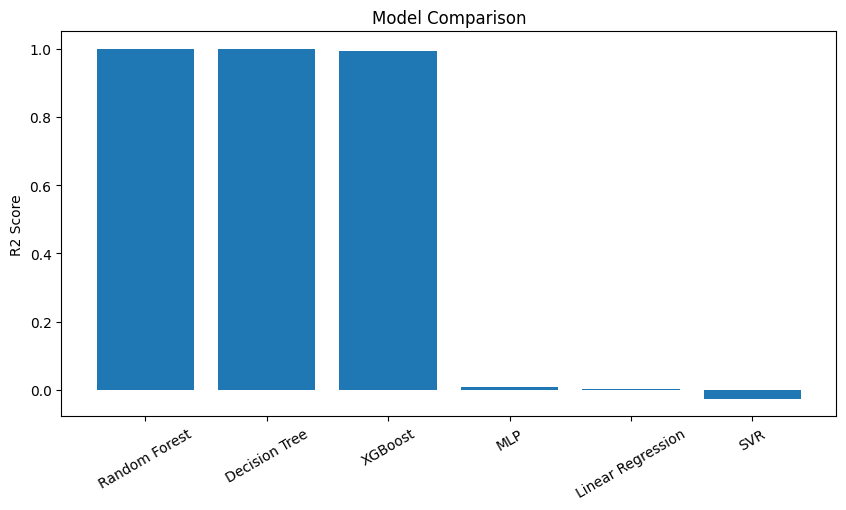

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"],results_df["R2 Score"])

plt.xticks(rotation=30)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

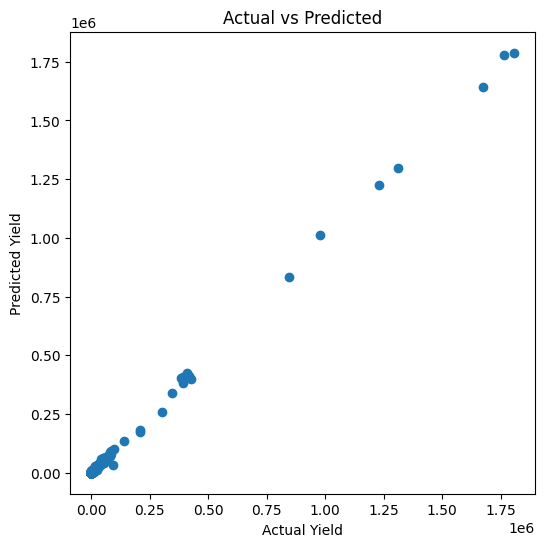

In [ ]:
prediction = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
joblib.dump(best_model,"crop_yield_model.pkl")

joblib.dump(scaler,"scaler.pkl")

joblib.dump(label_encoders,"label_encoders.pkl")

print("Saved Successfully")

Saved Successfully


In [ ]:
from google.colab import files

files.download("crop_yield_model.pkl")

files.download("scaler.pkl")

files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test data
y_pred = best_model.predict(X_test)

# If your best model is SVR or MLP, use:
# y_pred = best_model.predict(X_test_scaled)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))
print("Approximate Accuracy (%):", round(r2 * 100, 2), "%")

MAE : 1170.7315
RMSE: 4193.9043
R² Score: 0.999
Approximate Accuracy (%): 99.9 %


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, model in models.items():

    if name in ["SVR", "MLP"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    accuracy = r2 * 100

    results.append([name, mae, rmse, r2, accuracy])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score", "Accuracy (%)"]
)

results_df = results_df.sort_values(by="R² Score", ascending=False)

print(results_df)

               Model           MAE           RMSE  R² Score  Accuracy (%)
2      Random Forest   1170.731485    4193.904274  0.999000     99.900048
1      Decision Tree   1449.834023    6678.315411  0.997466     99.746552
5            XGBoost   2902.733976   10473.764221  0.993766     99.376609
4                MLP  33230.110203  132147.136262  0.007637      0.763733
0  Linear Regression  33316.942468  132464.166130  0.002870      0.287013
3                SVR  22450.018192  134393.722860 -0.026391     -2.639109


In [ ]:
!pip install streamlit pyngrok joblib scikit-learn xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files
print("Upload: crop_yield_model.pkl, scaler.pkl, label_encoders.pkl")
uploaded = files.upload()

Upload: crop_yield_model.pkl, scaler.pkl, label_encoders.pkl


Saving crop yield.csv to crop yield (2).csv


In [ ]:
print("Upload yield_df.csv (same file used in Phase 1)")
uploaded2 = files.upload()

Upload yield_df.csv (same file used in Phase 1)


Saving crop_yield_model.pkl to crop_yield_model (1).pkl
Saving label_encoders.pkl to label_encoders (1).pkl
Saving scaler.pkl to scaler (1).pkl


In [ ]:
import pandas as pd
import joblib

label_encoders = joblib.load("label_encoders.pkl")
df = pd.read_csv("crop yield (2).csv").dropna()

df_encoded = df.copy()
for col, le in label_encoders.items():
    df_encoded[col] = le.transform(df_encoded[col])

target = "yield"
X = df_encoded.drop(target, axis=1)
feature_columns = X.columns.tolist()

feature_stats = {}
for col in feature_columns:
    if col in label_encoders:
        feature_stats[col] = {"type": "categorical", "options": list(label_encoders[col].classes_)}
    else:
        feature_stats[col] = {
            "type": "numeric",
            "min": float(df[col].min()),
            "max": float(df[col].max()),
            "mean": float(df[col].mean())
        }

yield_stats = {
    "min": float(df[target].min()),
    "q25": float(df[target].quantile(0.25)),
    "median": float(df[target].median()),
    "q75": float(df[target].quantile(0.75)),
    "max": float(df[target].max())
}

joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(feature_stats, "feature_stats.pkl")
joblib.dump(yield_stats, "yield_stats.pkl")

print("Feature columns:", feature_columns)

Feature columns: ['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit']


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Crop Yield Forecasting Agent", page_icon="🌾", layout="wide")

@st.cache_resource
def load_artifacts():
    model = joblib.load("crop_yield_model.pkl")
    scaler = joblib.load("scaler.pkl")
    label_encoders = joblib.load("label_encoders.pkl")
    feature_columns = joblib.load("feature_columns.pkl")
    feature_stats = joblib.load("feature_stats.pkl")
    yield_stats = joblib.load("yield_stats.pkl")
    return model, scaler, label_encoders, feature_columns, feature_stats, yield_stats

model, scaler, label_encoders, feature_columns, feature_stats, yield_stats = load_artifacts()

st.sidebar.title("🌾 Crop Yield Forecasting Agent")
page = st.sidebar.radio("Navigate", ["Single Prediction", "Batch Yield Report", "Farm Planning Assistant", "About"])

def encode_row(raw_dict):
    row = {}
    for col in feature_columns:
        val = raw_dict[col]
        if col in label_encoders:
            le = label_encoders[col]
            try:
                val = le.transform([val])[0]
            except ValueError:
                val = 0
        row[col] = val
    return pd.DataFrame([row], columns=feature_columns)

def predict_yield(raw_dict):
    X_input = encode_row(raw_dict)
    return model.predict(X_input)[0]

def classify_yield(pred):
    if pred <= yield_stats["q25"]:
        return "Low"
    elif pred <= yield_stats["q75"]:
        return "Medium"
    return "High"

def generate_report(raw_dict, pred):
    category = classify_yield(pred)
    lines = []
    lines.append(f"Predicted yield: **{pred:,.2f}** units.")
    lines.append(f"Category: **{category}** (historical range: {yield_stats['min']:,.0f} - {yield_stats['max']:,.0f}).")

    rain_col = next((c for c in feature_columns if "rain" in c.lower()), None)
    pest_col = next((c for c in feature_columns if "pestic" in c.lower()), None)
    temp_col = next((c for c in feature_columns if "temp" in c.lower()), None)

    if rain_col and feature_stats[rain_col]["type"] == "numeric":
        avg = feature_stats[rain_col]["mean"]
        val = raw_dict[rain_col]
        if val < avg * 0.7:
            lines.append(f"🌧️ Rainfall input ({val}) is well below the historical average ({avg:.1f}). Consider irrigation planning.")
        elif val > avg * 1.3:
            lines.append("🌧️ Rainfall is unusually high — plan for drainage or waterlogging risk.")

    if pest_col and feature_stats[pest_col]["type"] == "numeric":
        avg = feature_stats[pest_col]["mean"]
        val = raw_dict[pest_col]
        if val < avg * 0.5:
            lines.append("🐛 Pesticide usage is low relative to the historical average — monitor for pest pressure.")

    if temp_col and feature_stats[temp_col]["type"] == "numeric":
        avg = feature_stats[temp_col]["mean"]
        val = raw_dict[temp_col]
        span = feature_stats[temp_col]["max"] - feature_stats[temp_col]["min"]
        if span > 0 and abs(val - avg) > span * 0.25:
            lines.append("🌡️ Average temperature deviates notably from historical norms — factor in crop heat/cold stress tolerance.")

    if category == "Low":
        lines.append("📌 Recommendation: review soil health, fertilizer timing, and irrigation scheduling to improve output.")
    elif category == "High":
        lines.append("📌 Recommendation: prepare adequate storage and logistics capacity for a strong harvest.")
    else:
        lines.append("📌 Recommendation: yield is on par with historical norms — maintain current practices and monitor weather.")

    return category, lines

# ---------------- Single Prediction ----------------
if page == "Single Prediction":
    st.title("🌾 Single Farm Yield Prediction")
    st.write("Enter farm and environmental details to get a yield forecast and recommendation report.")

    col1, col2 = st.columns(2)
    raw_dict = {}
    for i, col in enumerate(feature_columns):
        target_col = col1 if i % 2 == 0 else col2
        info = feature_stats[col]
        if info["type"] == "categorical":
            raw_dict[col] = target_col.selectbox(col, info["options"])
        else:
            raw_dict[col] = target_col.number_input(
                col,
                min_value=float(info["min"]),
                max_value=float(info["max"]) * 1.5,
                value=float(info["mean"])
            )

    farm_area = st.number_input("Farm area (hectares) — for production estimate", min_value=0.0, value=1.0)

    if st.button("Predict Yield"):
        pred = predict_yield(raw_dict)
        category, report_lines = generate_report(raw_dict, pred)

        m1, m2, m3 = st.columns(3)
        m1.metric("Predicted Yield", f"{pred:,.2f}")
        m2.metric("Category", category)
        m3.metric("Est. Total Production", f"{pred * farm_area:,.2f}")

        st.subheader("📋 Yield Report")
        for line in report_lines:
            st.markdown("- " + line)

# ---------------- Batch Yield Report ----------------
elif page == "Batch Yield Report":
    st.title("📊 Batch Yield Report")
    st.write("Upload a CSV with the same raw columns used in training (before encoding).")
    st.write("Expected columns:", feature_columns)

    file = st.file_uploader("Upload CSV", type=["csv"])
    if file is not None:
        batch_df = pd.read_csv(file)
        preds = []
        for _, row in batch_df.iterrows():
            raw_dict = {col: row[col] for col in feature_columns}
            preds.append(predict_yield(raw_dict))
        batch_df["Predicted_Yield"] = preds
        batch_df["Category"] = [classify_yield(p) for p in preds]

        st.dataframe(batch_df)

        st.subheader("Summary")
        st.bar_chart(batch_df["Category"].value_counts())

        csv = batch_df.to_csv(index=False).encode("utf-8")
        st.download_button("Download Report CSV", csv, "yield_report.csv", "text/csv")

# ---------------- Farm Planning Assistant ----------------
elif page == "Farm Planning Assistant":
    st.title("🧭 Farm Planning Assistant")
    st.write("See how changing one factor affects predicted yield, holding everything else constant.")

    base_dict = {}
    for col in feature_columns:
        info = feature_stats[col]
        if info["type"] == "categorical":
            base_dict[col] = st.selectbox(f"Base value: {col}", info["options"], key="base_" + col)
        else:
            base_dict[col] = info["mean"]

    numeric_cols = [c for c in feature_columns if feature_stats[c]["type"] == "numeric"]
    if numeric_cols:
        vary_col = st.selectbox("Factor to vary", numeric_cols)
        info = feature_stats[vary_col]
        values = np.linspace(info["min"], info["max"], 15)
        preds = []
        for v in values:
            trial = dict(base_dict)
            trial[vary_col] = v
            preds.append(predict_yield(trial))

        chart_df = pd.DataFrame({vary_col: values, "Predicted Yield": preds}).set_index(vary_col)
        st.line_chart(chart_df)

        best_idx = int(np.argmax(preds))
        st.success(f"Highest predicted yield ({preds[best_idx]:,.2f}) occurs around {vary_col} = {values[best_idx]:.2f}")
    else:
        st.info("No numeric features available to vary.")

# ---------------- About ----------------
else:
    st.title("About this Agent")
    st.write("""
    This AI agent uses the trained ML model from Phase 1 to:
    - Predict crop yield from farm/environmental inputs
    - Generate a readable yield report with statistical context
    - Estimate total production from farm area
    - Support farm planning through batch analysis and what-if simulations
    """)

Writing app.py


In [ ]:
!pip uninstall -y pyngrok
!pip install -q pyngrok==7.2.8

In [ ]:
from pyngrok import ngrok
import getpass

# Stop any existing tunnels
ngrok.kill()

# Paste your ngrok authtoken only once per Colab session
NGROK_AUTH_TOKEN = getpass.getpass("3Gnfb6jyxxi2SBXWDcRx8OKtXaI_46mgjH3fDrQxTMkxoErZS: ")

# Authenticate
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("✅ Ngrok authentication successful.")

3Gnfb6jyxxi2SBXWDcRx8OKtXaI_46mgjH3fDrQxTMkxoErZS: ··········
✅ Ngrok authentication successful.


In [ ]:
import subprocess
import time
from pyngrok import ngrok

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0"
    ]
)

# Wait for Streamlit to start
time.sleep(8)

# Create HTTPS tunnel

# Ensure ngrok authentication token is set from previous cell
# tunnel = ngrok.connect(8501)
# The ngrok authentication token is set in a previous cell, ensure it is still active.
# If you encounter authentication issues, re-run the `getpass` cell.
tunnel = ngrok.connect(8501)

print("Public URL:", tunnel.public_url)

print("=" * 60)
print("✅ Crop Yield Prediction Agent is Live!")
print("🌐 URL:", tunnel.public_url)
print("=" * 60)

# Keep notebook alive
try:
    process.wait()
except KeyboardInterrupt:
    ngrok.kill()
    process.terminate()

Public URL: https://dumpling-constant-viewing.ngrok-free.dev
✅ Crop Yield Prediction Agent is Live!
🌐 URL: https://dumpling-constant-viewing.ngrok-free.dev


In [ ]:
!git clone https://github.com/jagadeeshy429-yt/Crop-Yield-Prediction-Agent.git

Cloning into 'Crop-Yield-Prediction-Agent'...


In [ ]:
import shutil
import os

# List of files to copy
files_to_copy = [
    "app.py",
    "crop_yield_model.pkl",
    "scaler.pkl",
    "label_encoders.pkl",
    "feature_columns.pkl",
    "feature_stats.pkl",
    "yield_stats.pkl"
]

destination_dir = "Crop-Yield-Prediction-Agent/"
source_dir = "/content/" # Explicitly define the source directory where files are located

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Copy all project files
for filename in files_to_copy:
    source_path = os.path.join(source_dir, filename) # Construct full source path
    try:
        shutil.copy(source_path, destination_dir)
        print(f"Copied {filename} to {destination_dir}")
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found at '{source_path}'. Please ensure it exists before running this cell.")
    except Exception as e:
        print(f"An error occurred while copying {filename}: {e}")

Copied app.py to Crop-Yield-Prediction-Agent/
Copied crop_yield_model.pkl to Crop-Yield-Prediction-Agent/
Copied scaler.pkl to Crop-Yield-Prediction-Agent/
Copied label_encoders.pkl to Crop-Yield-Prediction-Agent/
Copied feature_columns.pkl to Crop-Yield-Prediction-Agent/
Copied feature_stats.pkl to Crop-Yield-Prediction-Agent/
Copied yield_stats.pkl to Crop-Yield-Prediction-Agent/


In [ ]:
%cd Crop-Yield-Prediction-Agent

/content/Crop-Yield-Prediction-Agent/Crop-Yield-Prediction-Agent/Crop-Yield-Prediction-Agent


In [ ]:
!git config user.name "jagadeeshy429-yt"
!git config user.email "jagadeeshy429@gmail.com"

In [ ]:
!git add .

In [ ]:
!git commit -m "Initial upload"

[main (root-commit) 382b01b] Initial upload
 7 files changed, 187 insertions(+)
 create mode 100644 app.py
 create mode 100644 crop_yield_model.pkl
 create mode 100644 feature_columns.pkl
 create mode 100644 feature_stats.pkl
 create mode 100644 label_encoders.pkl
 create mode 100644 scaler.pkl
 create mode 100644 yield_stats.pkl


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address
